# Run a Batch Experiment for Several Values of xi

### Setup

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

from msean import load_config
from msean.measurements.batch import batch_experiment
from msean.measurements.properties import PropertyEnum

Load global configuration from file <b>configs/default.yaml</b>.

In [2]:
# Load configuration file
root = Path.cwd().parents[0] # go up from notebooks/ to project root
cfg = load_config(root / "configs" / "default.yaml")
runs_dir = root / "runs"

Intialize random number generator for experiment reproducibility.

In [3]:
rng = np.random.default_rng(cfg.seed)

### Run Batch Experiment
Here, we experiment with parameter xi of the connection function, for values in the range [1, 5], with a step value of 1. We store values for the following properties: average degree, density, clustering, degree distribution.

In [4]:
results, paths = batch_experiment(
        cfg=cfg,
        parent_dir=runs_dir,
        rng=rng,
        param_name="connection.r_0",
        param_values=[0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1, 0.12],
        properties=[
            PropertyEnum.DENSITY,
            PropertyEnum.CLUSTERING,
            PropertyEnum.AVERAGE_DEGREE,
            PropertyEnum.DEGREE_DISTRIBUTION,
            PropertyEnum.DEGREE_DISTRIBUTION_PER_LAYER,
            PropertyEnum.EMBEDDEDNESS_DISTRIBUTION,
            PropertyEnum.CLUSTERING_DISTRIBUTION,
            PropertyEnum.EDGE_LENGTH_DISTRIBUTION,
        ],
    )

### Property Analysis

In [5]:
r0s = sorted(results.keys())

In [6]:
colors = plt.cm.viridis(np.linspace(0.15, 0.9, len(r0s)))
linestyles = ["-", "--", "-.", ":"]

### Average Degree

Aggregate plot example for a global property (average degree):

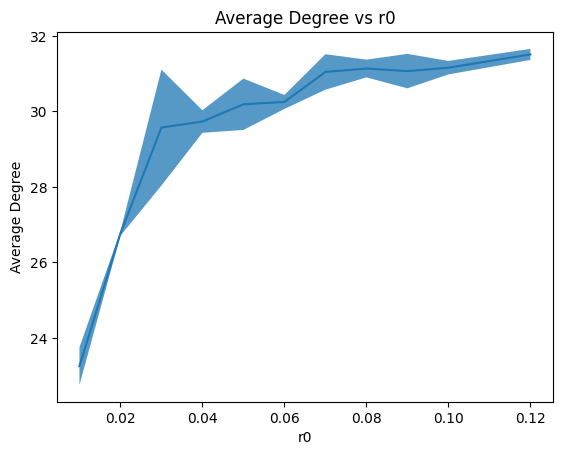

In [26]:
means = np.array([results[r0][PropertyEnum.AVERAGE_DEGREE][0] for r0 in r0s])
stds = np.array([results[r0][PropertyEnum.AVERAGE_DEGREE][1] for r0 in r0s])

lower = means - stds
upper = means + stds

fig = plt.figure()

plt.plot(r0s, means)
plt.fill_between(r0s, lower, upper, alpha=0.75)

plt.title("Average Degree vs r0")
plt.xlabel("r0")
plt.ylabel("Average Degree")

# Save in "plots" folder of the batch experiment directory
plt.savefig(paths["plots"] / "average_degree_vs_r0.png", bbox_inches="tight")
plt.show()

### Degree Distribution

Individual plot example for a distribution property (degree distribution):

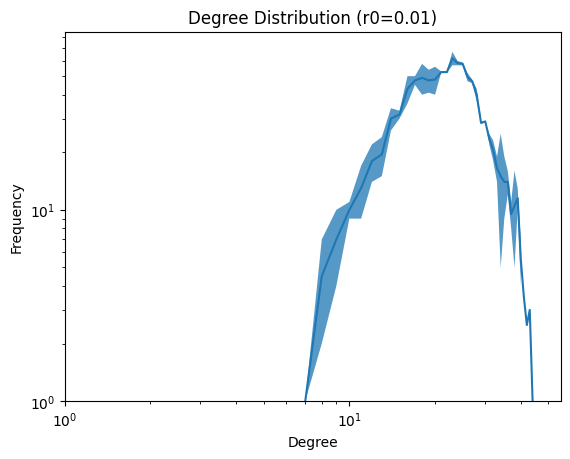

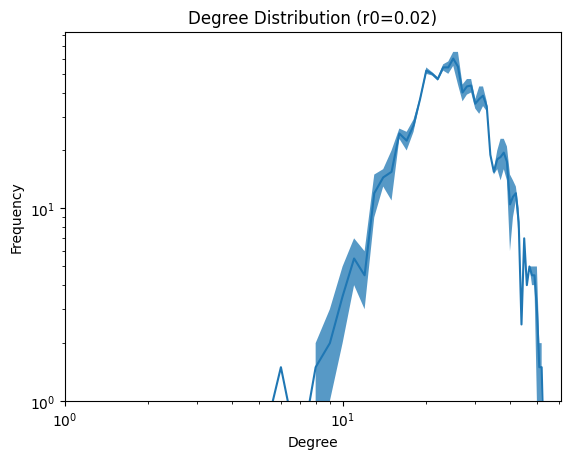

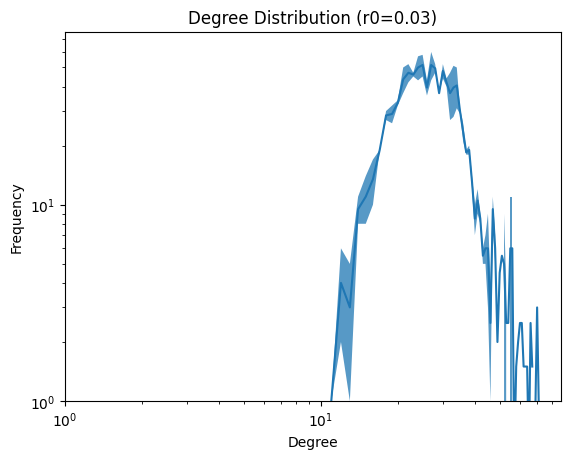

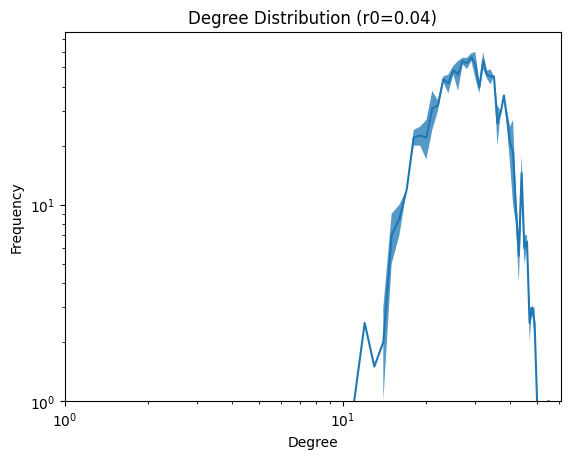

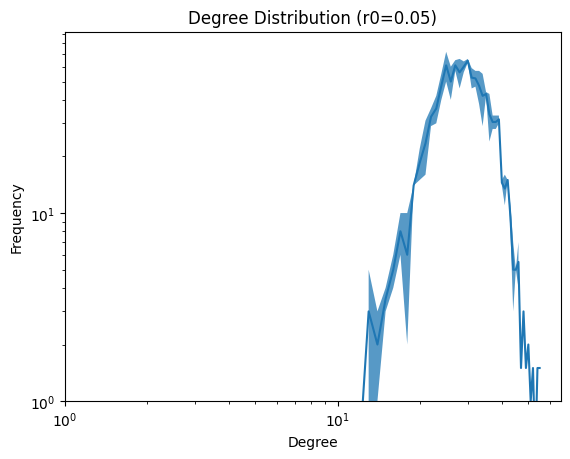

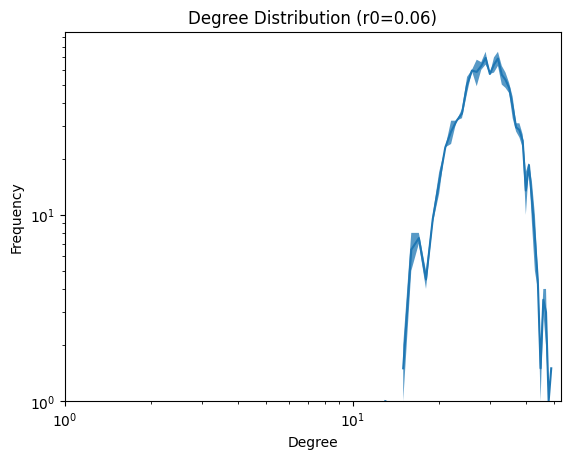

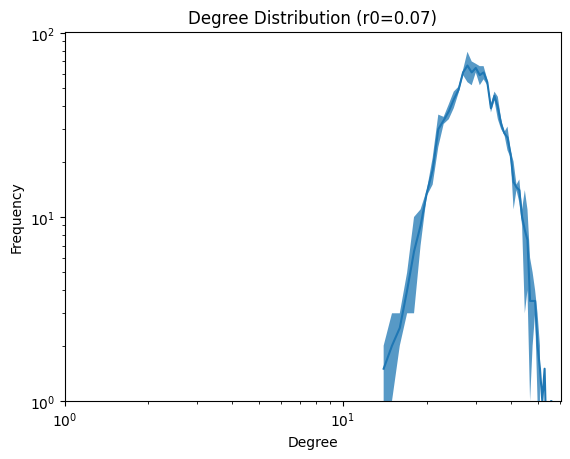

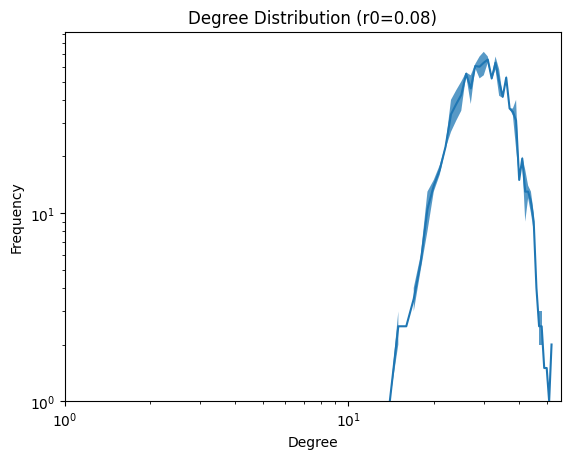

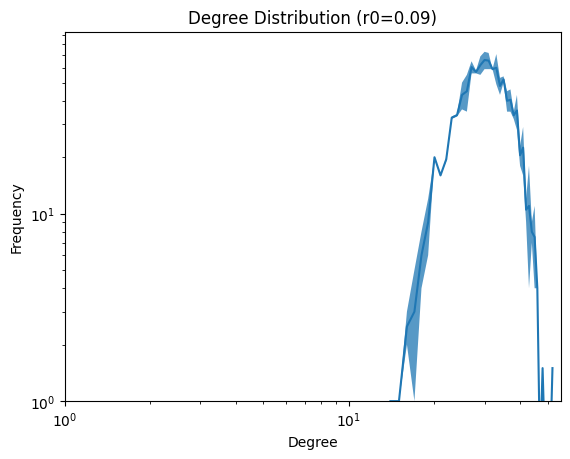

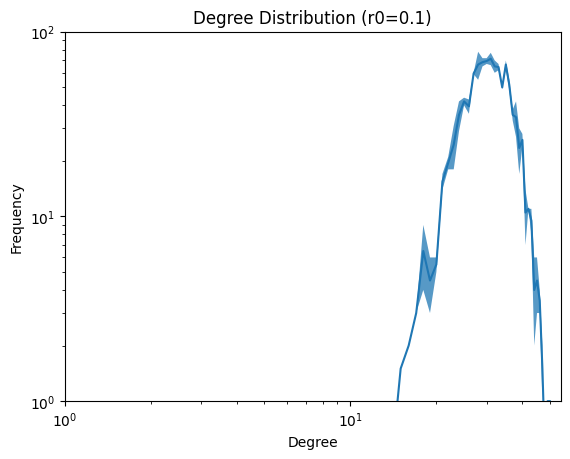

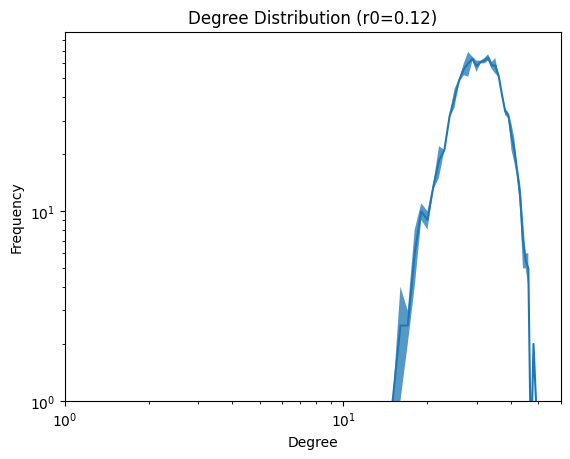

In [10]:
for r0 in r0s:
    deg_dist = results[r0][PropertyEnum.DEGREE_DISTRIBUTION][0]
    std_devs = results[r0][PropertyEnum.DEGREE_DISTRIBUTION][1]

    k = deg_dist[:, 0]
    freq = deg_dist[:, 1].astype(float)
    std = std_devs.astype(float)

    lower = freq - std
    upper = freq + std

    lower[lower <= 0] = np.nan
    upper[upper <= 0] = np.nan
    freq[freq <= 0] = np.nan

    fig = plt.figure()

    plt.plot(k, freq)
    plt.fill_between(k, lower, upper, alpha=0.75)

    plt.title(f"Degree Distribution (r0={r0})")
    plt.xlabel("Degree")
    plt.ylabel("Frequency")
    plt.xscale("log")
    plt.yscale("log")
    plt.xlim(1, plt.xlim()[1])
    plt.ylim(1, plt.ylim()[1])

    # Save in "plots" folder of the individual run
    plt.savefig(paths["batch_dir"] / f"r_0_{r0}" / "plots" / f"degree_distribution_r_0_{r0}.png", bbox_inches="tight")
    plt.show()

Aggregate plot example for a distribution property (degree distribution):

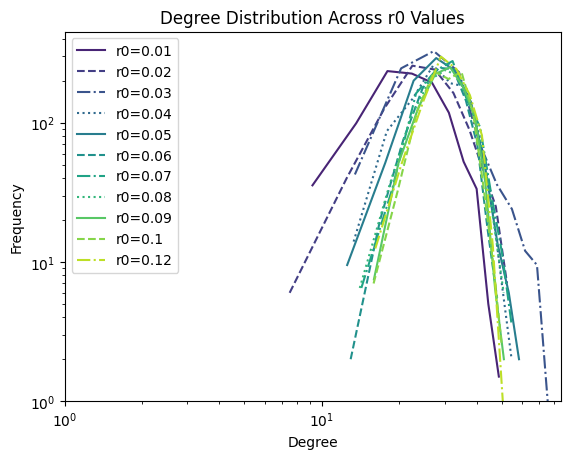

In [17]:
fig = plt.figure()

for i, r0 in enumerate(r0s):
    deg_dist = results[r0][PropertyEnum.DEGREE_DISTRIBUTION][0]
    std_devs = results[r0][PropertyEnum.DEGREE_DISTRIBUTION][1]

    k = deg_dist[:, 0]
    freq = deg_dist[:, 1]

    freqs, bin_edges = np.histogram(k, weights=freq)
    bin_mids = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    plt.plot(
        bin_mids,
        freqs,
        color=colors[i],
        linestyle=linestyles[i % len(linestyles)],
        label=f"r0={r0}"
    )

plt.title("Degree Distribution Across r0 Values")
plt.xlabel("Degree")
plt.ylabel("Frequency")
plt.xscale("log")
plt.yscale("log")
plt.xlim(1, plt.xlim()[1])
plt.ylim(1, plt.ylim()[1])
plt.legend()

# Save in "plots" folder of the batch experiment directory
plt.savefig(paths["plots"] / "degree_distribution_by_r_0.png", bbox_inches="tight")
plt.show()

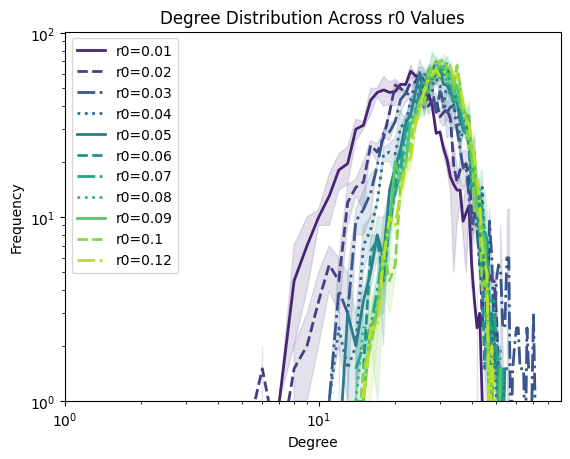

In [ ]:
# TODO: REMOVE?

fig = plt.figure()

colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(r0s)))
linestyles = ["-", "--", "-.", ":"]

for i, r0 in enumerate(r0s):
    deg_dist = results[r0][PropertyEnum.DEGREE_DISTRIBUTION][0]
    std_devs = results[r0][PropertyEnum.DEGREE_DISTRIBUTION][1]

    k = deg_dist[:, 0]
    freq = deg_dist[:, 1].astype(float)
    std = std_devs.astype(float)

    lower = freq - std
    upper = freq + std

    freq[freq <= 0] = np.nan
    lower[lower <= 0] = np.nan
    upper[upper <= 0] = np.nan

    plt.plot(
        k,
        freq,
        color=colors[i],
        linestyle=linestyles[i % len(linestyles)],
        linewidth=2,
        label=f"r0={r0}"
    )

    plt.fill_between(
        k,
        lower,
        upper,
        color=colors[i],
        alpha=0.15
    )

plt.title("Degree Distribution Across r0 Values")
plt.xlabel("Degree")
plt.ylabel("Frequency")
plt.xscale("log")
plt.yscale("log")
plt.xlim(left=1)
plt.ylim(bottom=1)
plt.legend()

plt.savefig(paths["plots"] / "degree_distribution_by_r_0.png", bbox_inches="tight")
plt.show()

### Degree Distribution Per Layer

In [18]:
layer_sizes = {
    'l1': 100,
    'l2': 150,
    'l3': 200,
    'l4': 250,
    'l5': 300,
    'l6': 350
}

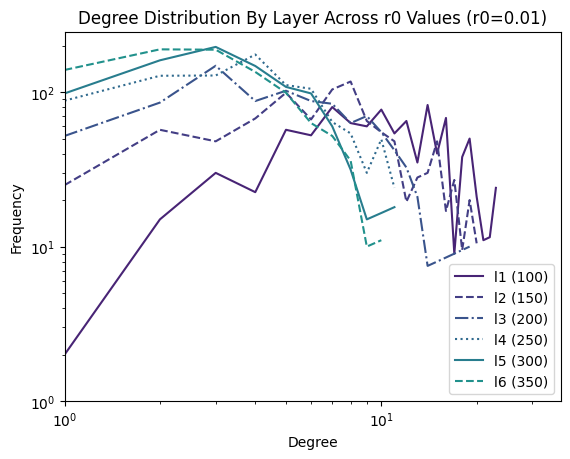

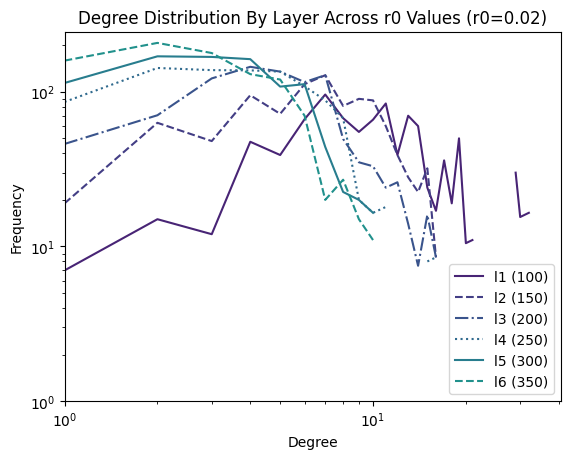

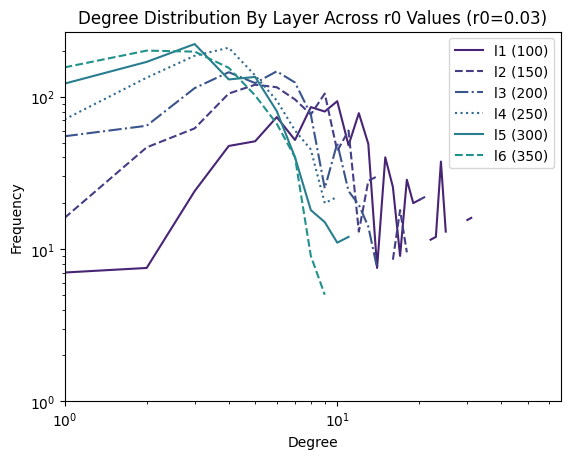

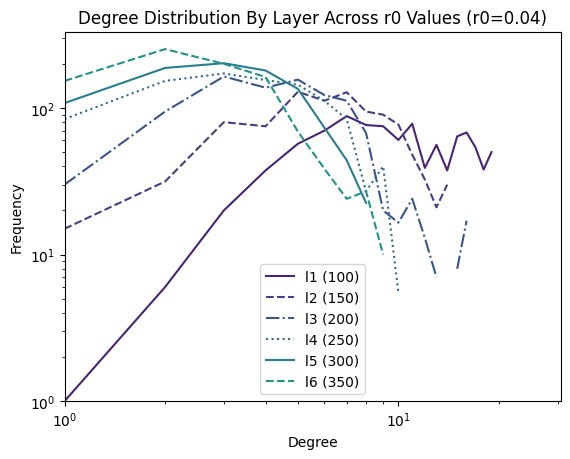

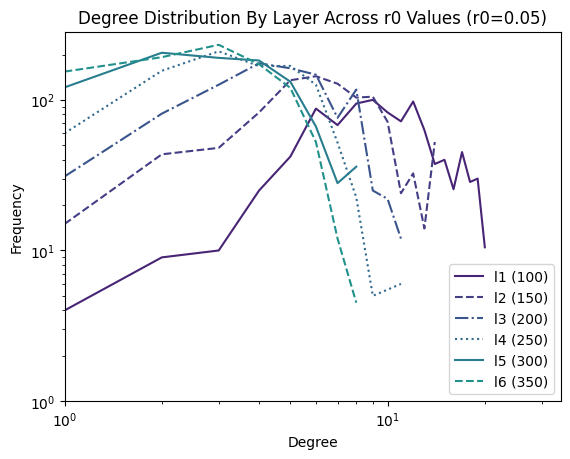

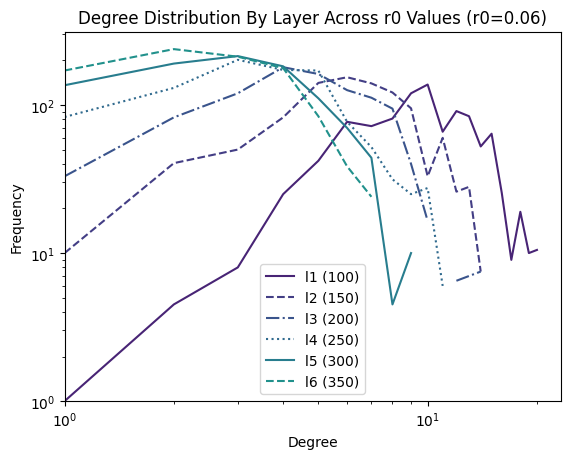

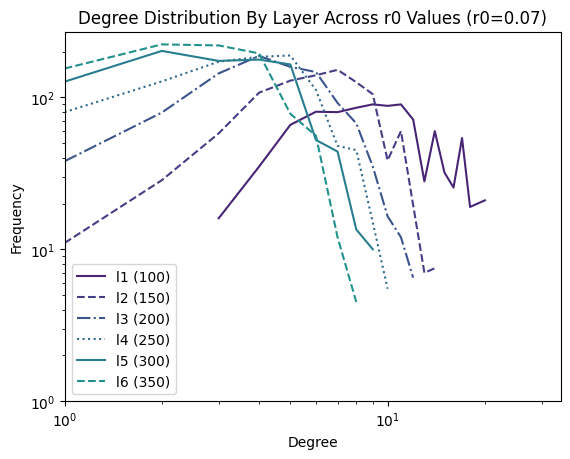

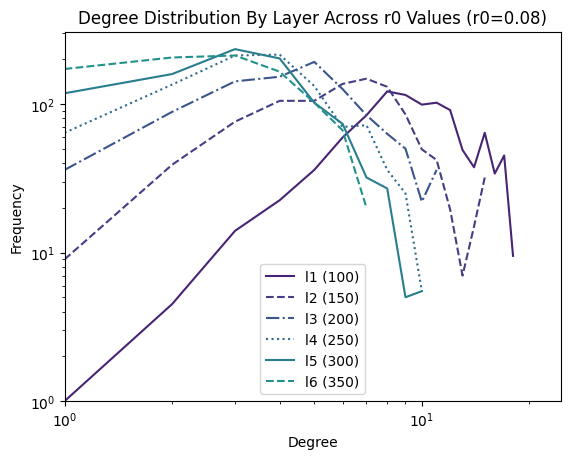

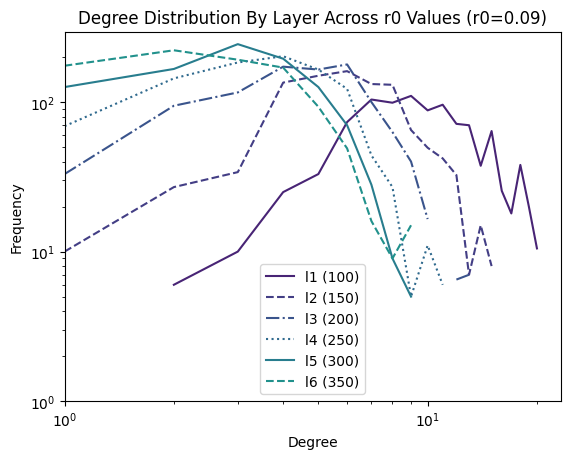

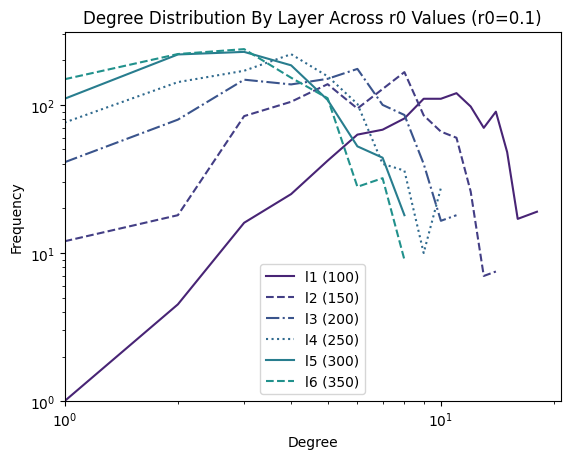

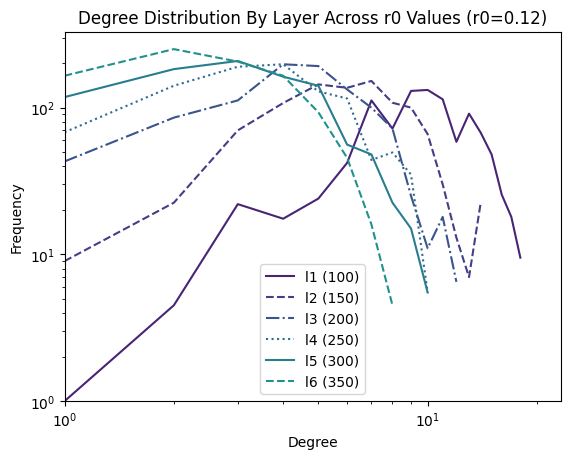

In [20]:
for i, r0 in enumerate(r0s):
    deg_dists_layers = results[r0][PropertyEnum.DEGREE_DISTRIBUTION_PER_LAYER]
    fig = plt.figure()

    for j, (dist, label) in enumerate(zip(deg_dists_layers, cfg.network.layer_labels)):
        dist = dist[0]
        k = dist[:, 0]
        freq = dist[:, 1].astype(float)

        freq[freq <= 0] = np.nan
        freq[k <= 0] = np.nan

        plt.plot(
            k,
            freq,
            color=colors[j],
            linestyle=linestyles[j % len(linestyles)],
            label=f"{label} ({layer_sizes[label]})"
        )

    plt.title(f"Degree Distribution By Layer Across r0 Values (r0={r0})")
    plt.xlabel("Degree")
    plt.ylabel("Frequency")
    plt.xscale("log")
    plt.yscale("log")
    plt.xlim(1, plt.xlim()[1])
    plt.ylim(1, plt.ylim()[1])
    plt.legend()

    # Save in "plots" folder of the individual run
    plt.savefig(paths["batch_dir"] / f"r_0_{r0}" / "plots" / f"degree_distribution_layer_r_0_{r0}.png", bbox_inches="tight")
    plt.show()

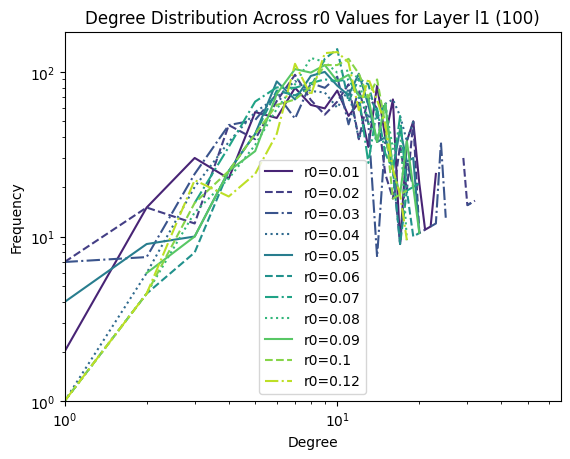

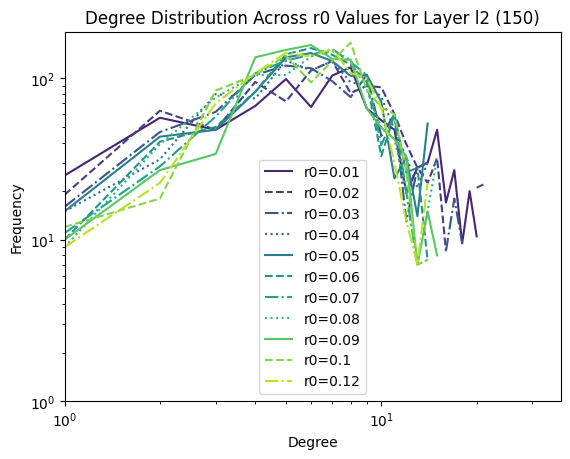

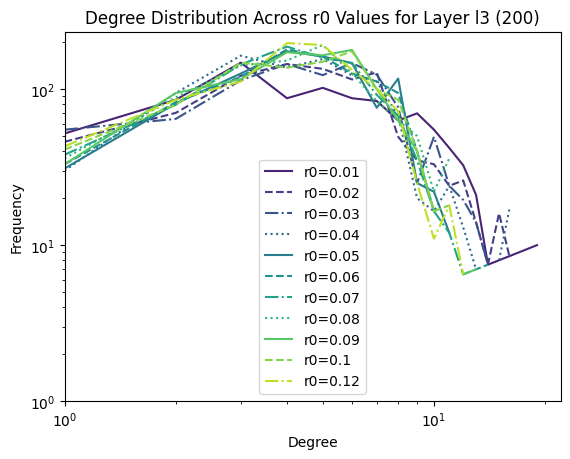

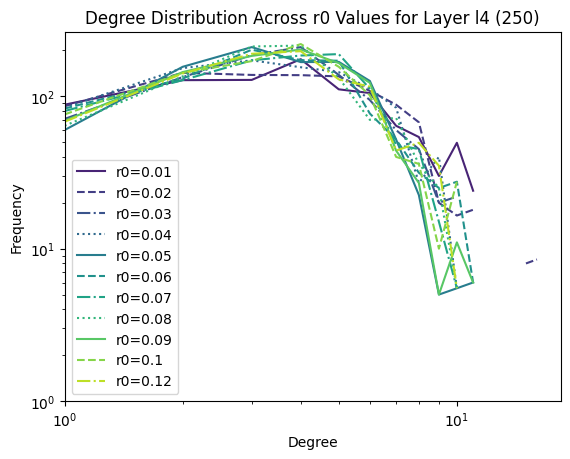

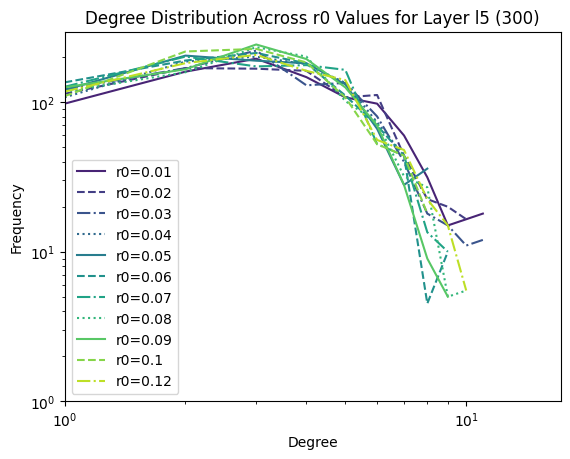

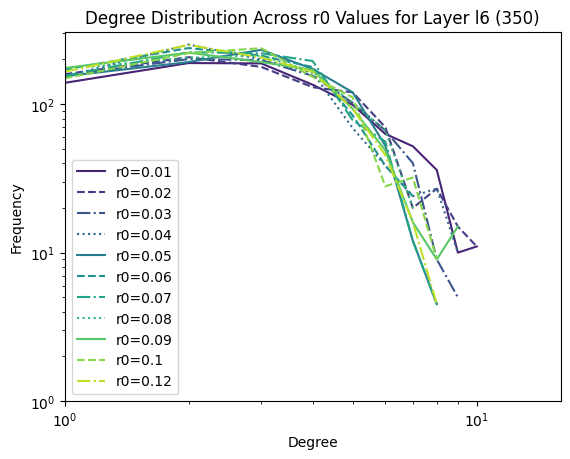

In [22]:
# Plot one aggregate degree-distribution figure per layer,
# with one line per r0 value.

for layer_idx, layer_label in enumerate(cfg.network.layer_labels):
    fig = plt.figure()

    for i, r0 in enumerate(r0s):
        deg_dists_layers = results[r0][PropertyEnum.DEGREE_DISTRIBUTION_PER_LAYER]

        dist = deg_dists_layers[layer_idx][0]

        k = dist[:, 0]
        freq = dist[:, 1].astype(float)
        
        freq[freq <= 0] = np.nan
        freq[k <= 0] = np.nan

        plt.plot(
            k,
            freq,
            color=colors[i],
            linestyle=linestyles[i % len(linestyles)],
            label=f"r0={r0}"
        )

    plt.title(
        f"Degree Distribution Across r0 Values "
        f"for Layer {layer_label} ({layer_sizes[layer_label]})"
    )
    plt.xlabel("Degree")
    plt.ylabel("Frequency")
    plt.xscale("log")
    plt.yscale("log")
    plt.xlim(1, plt.xlim()[1])
    plt.ylim(1, plt.ylim()[1])
    plt.legend()

    plt.savefig(
        paths["batch_dir"] / "plots" / f"degree_distribution_layer_{layer_label}_all_r_0.png",
        bbox_inches="tight"
    )
    plt.show()

### Other Plots

In [23]:
from msean.measurements.batch import GLOBAL_PROPERTIES, DISTRIBUTION_PROPERTIES

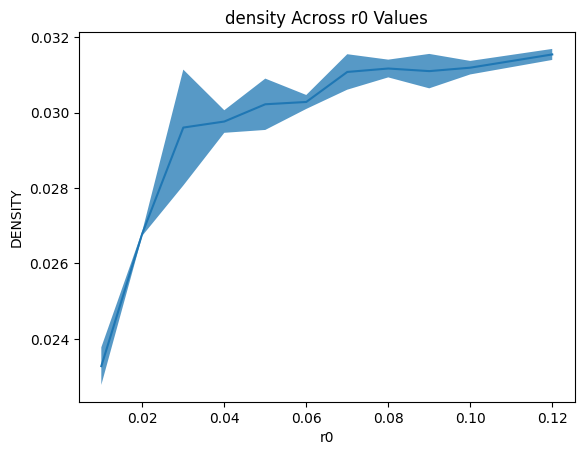

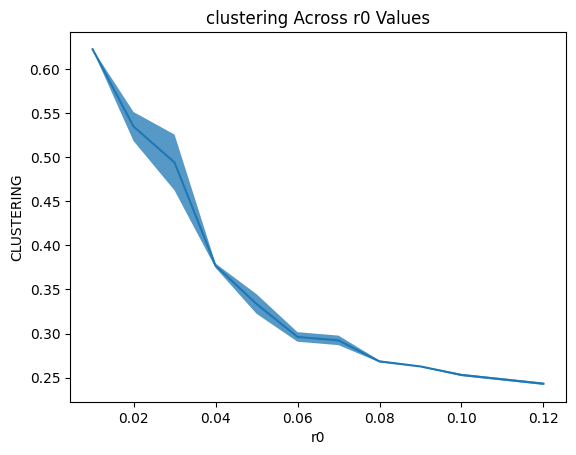

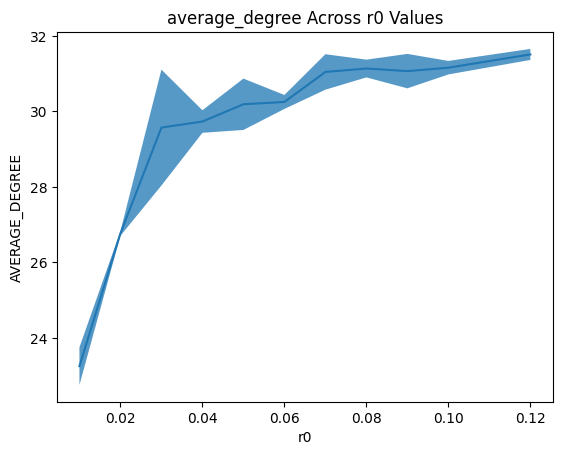

In [27]:
for prop in GLOBAL_PROPERTIES:
    means = np.array([results[r0][prop][0] for r0 in r0s])
    stds = np.array([results[r0][prop][1] for r0 in r0s])

    lower = means - stds
    upper = means + stds

    plt.figure()
    plt.plot(r0s, means)
    plt.fill_between(r0s, lower, upper, alpha=0.75)

    plt.title(f"{prop.name.lower()} Across r0 Values")
    plt.xlabel("r0")
    plt.ylabel(prop.name)

    plt.savefig(
        paths["batch_dir"] / "plots" / f"{prop.name.lower()}_vs_r0.png",
        bbox_inches="tight",
    )
    plt.show()

    # tune to clustering as well, see layers sizes in popnet

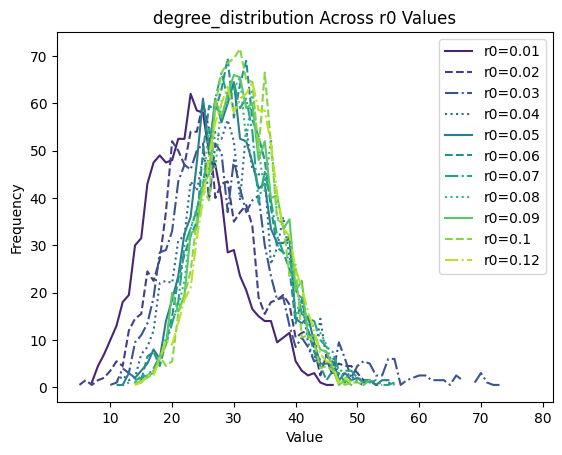

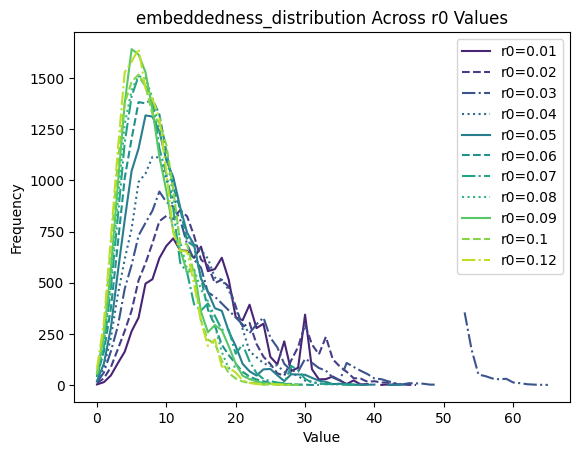

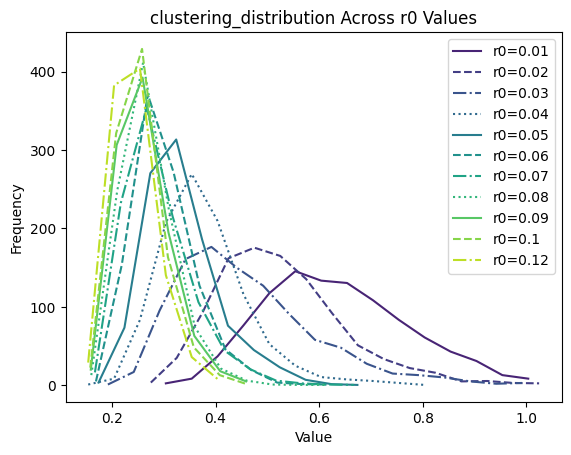

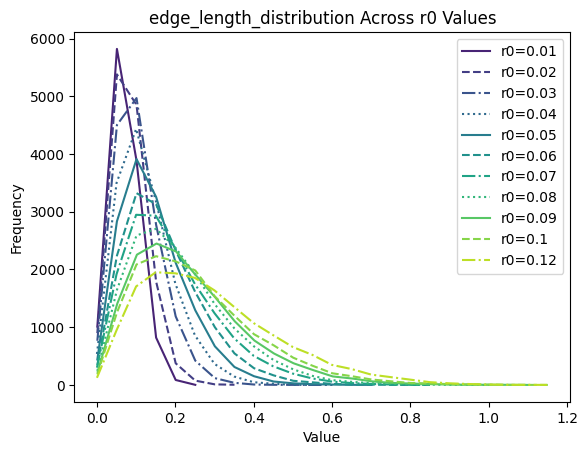

In [33]:
for prop in DISTRIBUTION_PROPERTIES:
    if prop == PropertyEnum.DEGREE_DISTRIBUTION_PER_LAYER:
        continue
    
    plt.figure()
    
    for i, r0 in enumerate(r0s):
        mean_dist, _ = results[r0][prop]
        x = mean_dist[:, 0]
        y = mean_dist[:, 1].astype(float)

        y[y <= 0] = np.nan
        
        plt.plot( x, y, color=colors[i], linestyle=linestyles[i % len(linestyles)], label=f"r0={r0}")

    plt.title(f"{prop.name.lower()} Across r0 Values")
    plt.xlabel("Value")
    plt.ylabel("Frequency")
    plt.legend()
    plt.savefig( paths["batch_dir"] / "plots" / f"{prop.name.lower()}_all_r0.png", bbox_inches="tight", )
    plt.show()

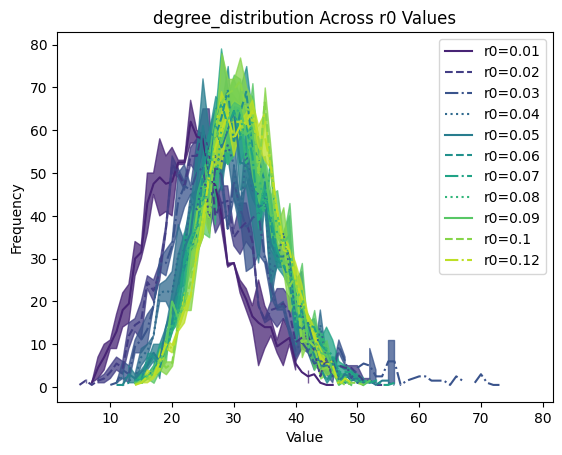

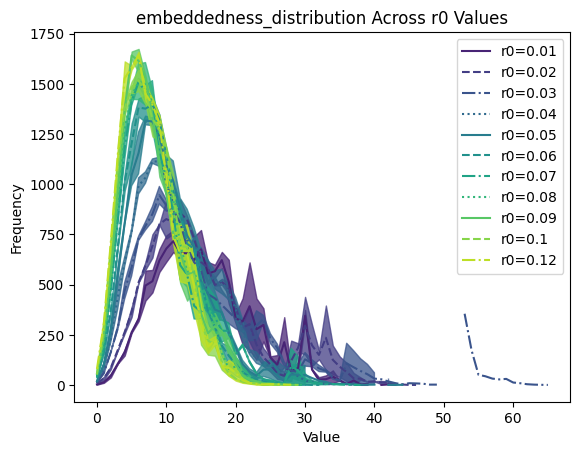

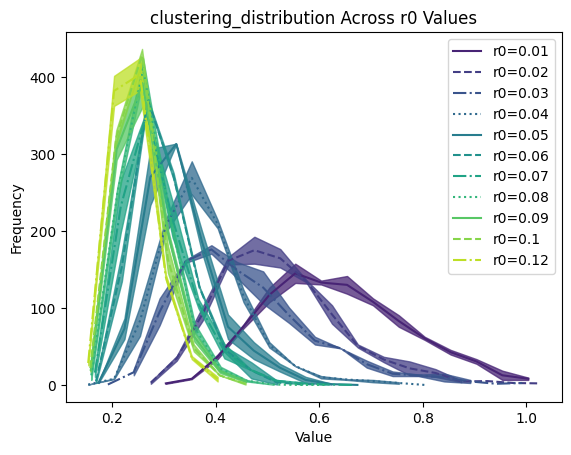

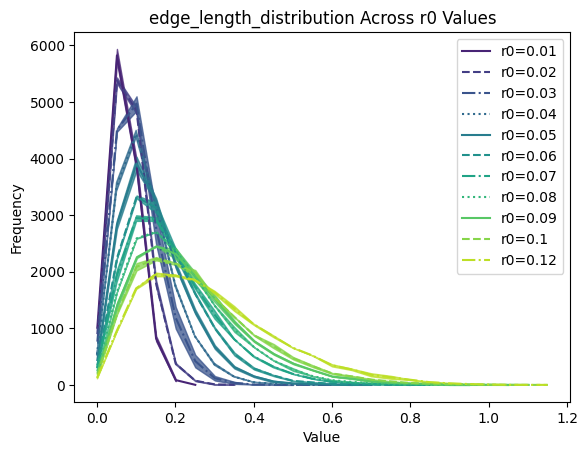

In [ ]:
#TODO: KEEP OR REVERT?

for prop in DISTRIBUTION_PROPERTIES:
    if prop == PropertyEnum.DEGREE_DISTRIBUTION_PER_LAYER:
        continue

    plt.figure()

    for i, r0 in enumerate(r0s):
        mean_dist, std_devs = results[r0][prop]

        x = mean_dist[:, 0]
        y = mean_dist[:, 1].astype(float)
        std = std_devs.astype(float)

        lower = y - std
        upper = y + std

        y[y <= 0] = np.nan
        lower[lower <= 0] = np.nan
        upper[upper <= 0] = np.nan

        plt.plot(
            x,
            y,
            color=colors[i],
            linestyle=linestyles[i % len(linestyles)],
            label=f"r0={r0}",
        )

        plt.fill_between(
            x,
            lower,
            upper,
            color=colors[i],
            alpha=0.75,
        )

    plt.title(f"{prop.name.lower()} Across r0 Values")
    plt.xlabel("Value")
    plt.ylabel("Frequency")
    plt.legend()

    plt.savefig(
        paths["batch_dir"] / "plots" / f"{prop.name.lower()}_all_r0.png",
        bbox_inches="tight",
    )
    plt.show()

choose two extreme r0 values, show edge length distribution and then get a visualization of the resulting networks, shows the clustering as well
ignore layers for now

1. show deg dist are as expected
2. edge len
3. clustering